Device: cuda
Output directory: /kaggle/working/


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Encoder loaded: BAAI/bge-m3
Loaded 166 clean triples (2-element gold aspect labels)

Evaluating V1 (narrative prose) …
  Done. CoA: 60.2% (p=0.0453)
Evaluating V2 (role-label steps) …
  Done. CoA: 64.5% (p=0.0028)
Evaluating V3 (compact phrases) …
  Done. CoA: 57.2% (p=0.0483)


  TABLE 1: Aspect Informativeness — % positive > negative similarity
  (paired t-test; * p<0.05, ** p<0.01, *** p<0.001)
              Version    Aspect  % pos>neg  Mean diff  Cohen's d             95% CI     t  p (t-test)  p (Wilcox) Sig.
 V1 (narrative prose) Full text       59.0     0.0092      0.213 [+0.0027, +0.0158] 2.742      0.0068      0.0124   **
 V1 (narrative prose)       CoA       60.2     0.0069      0.157 [+0.0002, +0.0135] 2.017      0.0453      0.0080    *
 V1 (narrative prose)  Outcomes       58.4     0.0075      0.186 [+0.0014, +0.0135] 2.395      0.0177      0.0086    *
 V1 (narrative prose)     Theme       51.2     0.0012      0.038 [-0.0035, +0.0061] 0.487      0.6270      0.4560 n.s.
V2 (

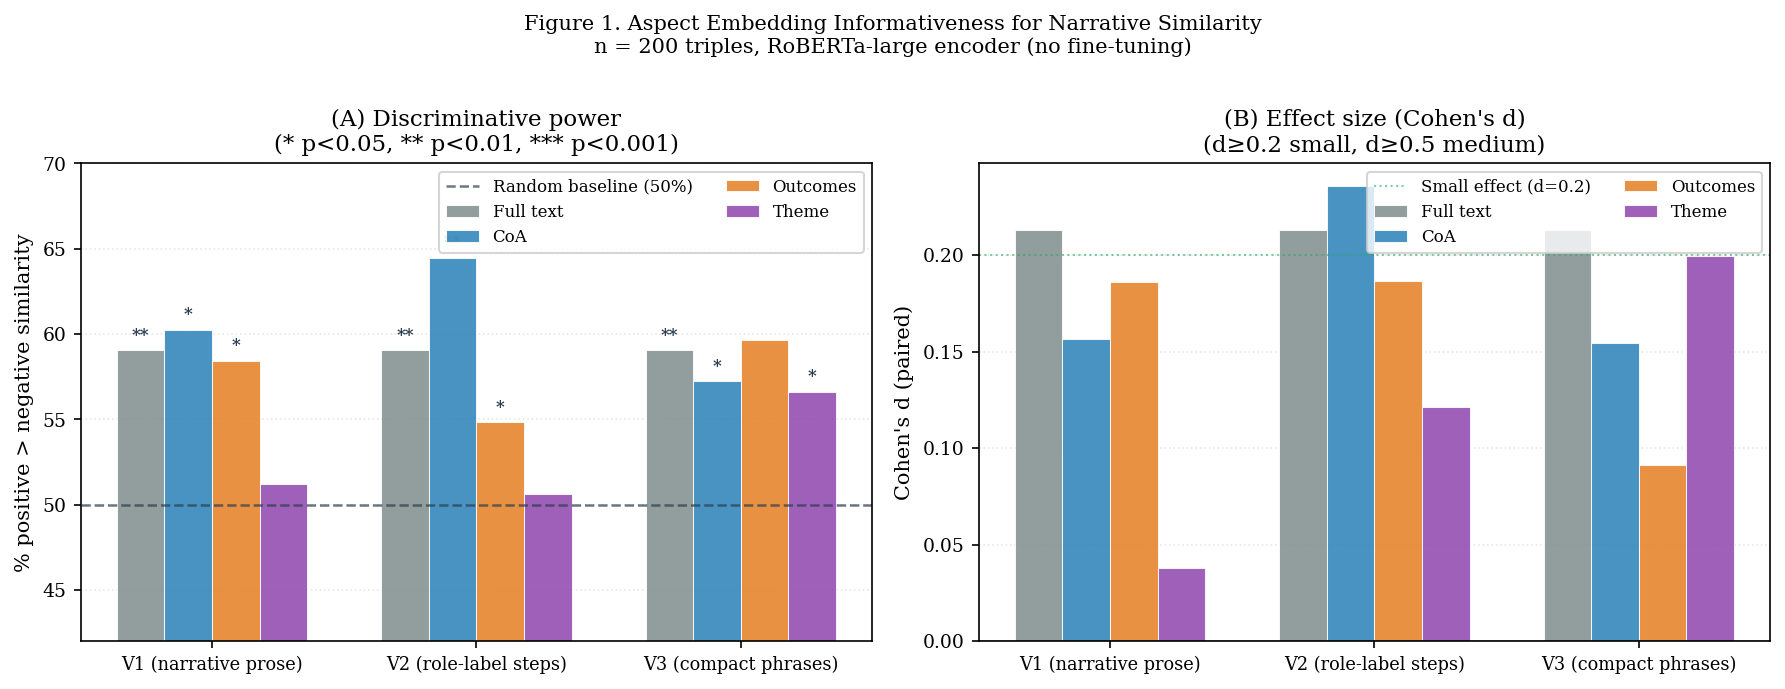

Saved: fig1_discriminative_power


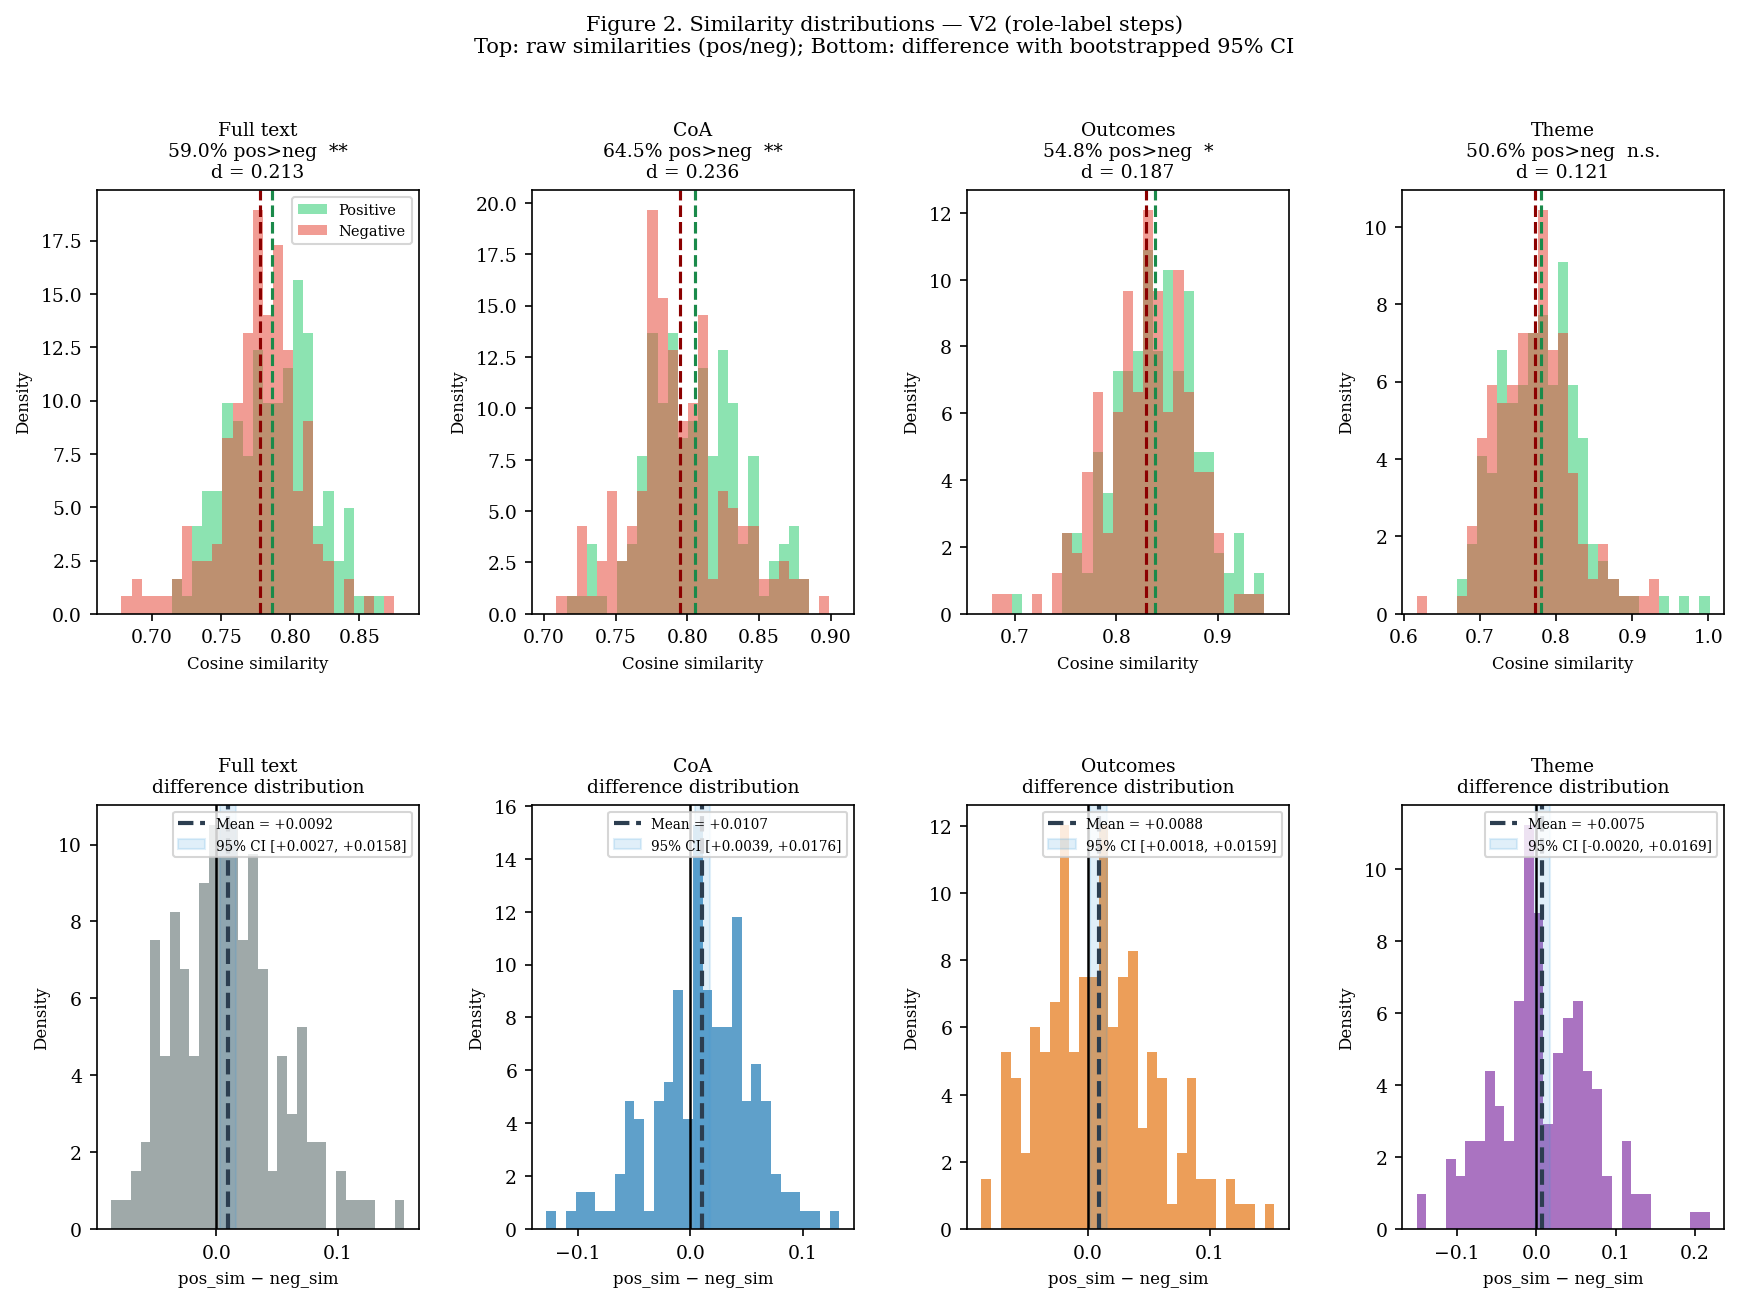

Saved: fig2_distributions


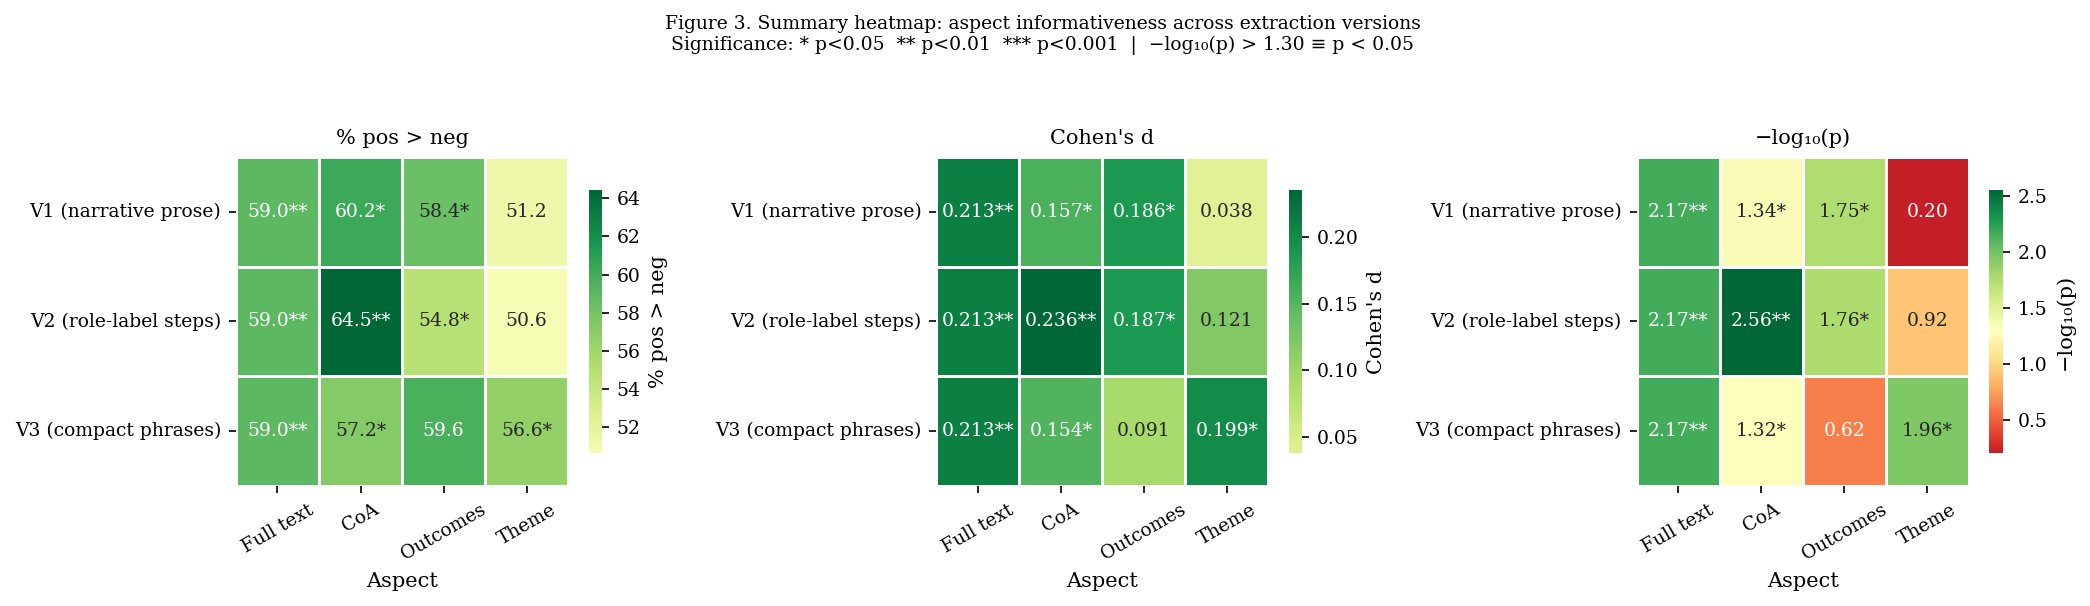

Saved: fig3_heatmap


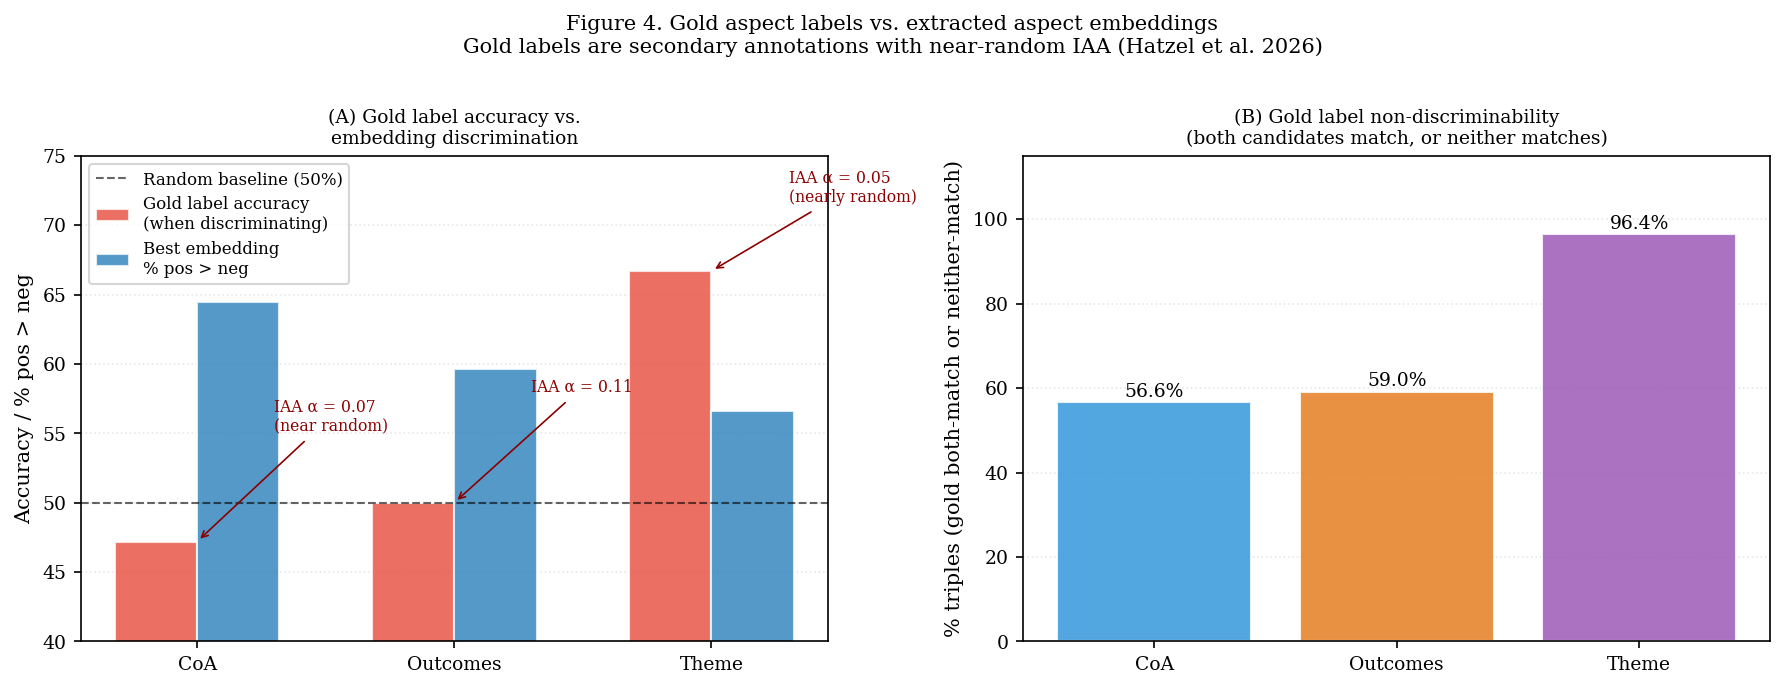

Saved: fig4_gold_vs_embedding


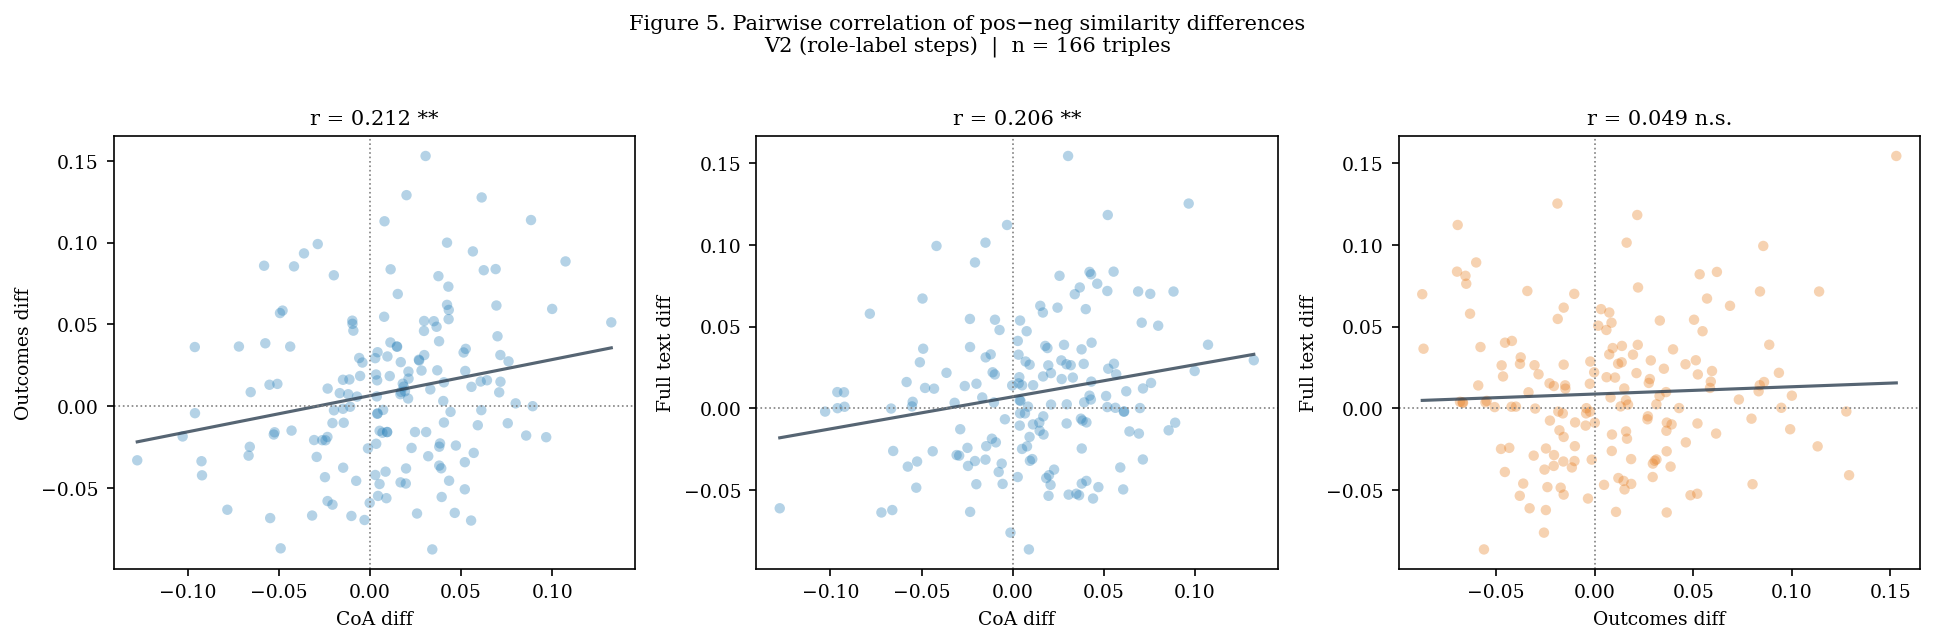

Saved: fig5_complementarity
Do extracted aspects discriminate better than random?
──────────────────────────────────────────────────────────
  V1 (narrative prose) / CoA: 60.2% pos>neg, d=0.157, p=0.0453 (significant)
  V1 (narrative prose) / Outcomes: 58.4% pos>neg, d=0.186, p=0.0177 (significant)
  V2 (role-label steps) / CoA: 64.5% pos>neg, d=0.236, p=0.0028 (significant)
  V2 (role-label steps) / Outcomes: 54.8% pos>neg, d=0.187, p=0.0173 (significant)
  V3 (compact phrases) / CoA: 57.2% pos>neg, d=0.154, p=0.0483 (significant)
  V3 (compact phrases) / Outcomes: 59.6% pos>neg, d=0.091, p=0.2416 (not significant)
All outputs saved to: /kaggle/working/
  fig1_discriminative_power.pdf/png
  fig2_distributions.pdf/png
  fig3_heatmap.pdf/png
  fig4_gold_vs_embedding.pdf/png
  fig5_complementarity.pdf/png
  table1_aspect_informativeness_bge_m3.csv
  table2_gold_labels_bge_m3.csv
  table3_complementarity_bge_m3.csv


In [ ]:
"""
Methodology
-----------
  • Updated model choice: BAAI/bge-m3 to better test whether short,
    compact aspects become more discriminative under a retrieval-oriented
    embedding model.
  • Encoder: BAAI/bge-m3
    (retrieval-oriented, multi-granularity embedding model,
    mean-pooled, L2-normalised, no fine-tuning at this stage)
  • Dataset: 200 human-annotated triples from dev set
  • For each triple: anchor, positive (gold closer candidate),
    negative (gold less similar candidate)
  • Metric: cosine similarity between aspect embeddings
  • Statistical tests: paired t-test, Wilcoxon signed-rank test,
    Cohen's d, Bootstrap 95% CI, Permutation test
  • All three extraction versions (V1, V2, V3) evaluated and compared
  • Gold aspect labels analysed as an independent reference
"""

import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import wilcoxon, pearsonr
from tqdm import tqdm
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
})

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

DATA_DIR   = "/kaggle/input/datasets/anisoaraana/aspect-aware-narrative-similarity/"
DEV_PATH   = DATA_DIR + "dev_track_a_labels.jsonl"

CACHE_PATHS = {
    "V1\n(narrative prose)":   DATA_DIR + "aspects_cache_v1.json",
    "V2\n(role-label steps)":   DATA_DIR + "aspects_cache_v2.json",
    "V3\n(compact phrases)":  DATA_DIR + "aspects_cache_v3.json",
}
VERSION_LABELS = list(CACHE_PATHS.keys())

# Clean display labels for tables/text
CLEAN_LABELS = {
    "V1\n(narrative prose)":  "V1 (narrative prose)",
    "V2\n(role-label steps)":  "V2 (role-label steps)",
    "V3\n(compact phrases)": "V3 (compact phrases)",
}

MODEL_NAME  = "BAAI/bge-m3"
MAX_LEN     = 384
BATCH_SIZE  = 16
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
N_BOOTSTRAP = 5000
ALPHA       = 0.05
VIEWS       = ["full", "coa", "outcomes", "theme"]
VIEW_LABELS = {"full": "Full text", "coa": "CoA",
               "outcomes": "Outcomes", "theme": "Theme"}
VIEW_COLORS = {"full": "#7f8c8d", "coa": "#2980b9",
               "outcomes": "#e67e22", "theme": "#8e44ad"}
OUTPUT_DIR  = "/kaggle/working/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Output directory: {OUTPUT_DIR}")


# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

def _norm(text: str) -> str:
    return " ".join(str(text).split())


def load_cache(path: str) -> dict:
    if not Path(path).exists():
        return {}
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    cache = {}
    for k, v in raw.items():
        cache[_norm(k)] = {
            "coa":      (v.get("coa") or v.get("course_of_action") or "").strip(),
            "outcomes": (v.get("outcomes") or v.get("outcome") or "").strip(),
            "theme":    (v.get("theme") or v.get("abstract_theme") or "").strip(),
        }
    return cache


def load_dev_triples(path: str):
    """
    Load dev triples. Returns list of dicts with:
      anchor_text, text_a, text_b, text_a_is_closer,
      coa_labels [bool, bool], out_labels [bool, bool], thm_labels [bool, bool],
      human_labels [bool, bool]
    Only triples with 2-element gold aspect labels are included.
    """
    triples = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            d = json.loads(line)
            coa = d.get("course_of_actions", [])
            out = d.get("outcomes", [])
            thm = d.get("abstract_theme", [])
            if len(coa) == 2 and len(out) == 2 and len(thm) == 2:
                triples.append({
                    "anchor":      d["anchor_text"],
                    "text_a":      d["text_a"],
                    "text_b":      d["text_b"],
                    "label":       bool(d["text_a_is_closer"]),
                    "coa_labels":  coa,
                    "out_labels":  out,
                    "thm_labels":  thm,
                    "human_labels": d.get("human_labels", []),
                })
    print(f"Loaded {len(triples)} clean triples (2-element gold aspect labels)")
    return triples


def get_view_text(text: str, view: str, cache: dict) -> str:
    if view == "full":
        return text
    entry = cache.get(_norm(text), {})
    val   = entry.get(view, "").strip()
    return val if val else text   # graceful fallback to full text


# ══════════════════════════════════════════════════════════════════════════════
# ENCODER
# ══════════════════════════════════════════════════════════════════════════════

tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder    = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
encoder.eval()
print(f"Encoder loaded: {MODEL_NAME}")


def encode(texts: list) -> np.ndarray:
    embs = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i:i + BATCH_SIZE]
        enc   = tokenizer(batch, padding=True, truncation=True,
                          max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out  = encoder(**enc)
            tok  = out.last_hidden_state
            mask = enc["attention_mask"].unsqueeze(-1).float()
            emb  = (tok * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
            emb  = F.normalize(emb, p=2, dim=1)
        embs.append(emb.cpu().numpy())
    return np.vstack(embs)


# ══════════════════════════════════════════════════════════════════════════════
# STATISTICAL TOOLKIT
# ══════════════════════════════════════════════════════════════════════════════

def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    """Paired Cohen's d for the difference distribution."""
    diff = a - b
    return diff.mean() / (diff.std(ddof=1) + 1e-12)


def bootstrap_ci(a: np.ndarray, b: np.ndarray,
                 n: int = N_BOOTSTRAP, ci: float = 0.95) -> tuple:
    """Bootstrap confidence interval on mean(a - b)."""
    rng    = np.random.default_rng(42)
    diffs  = a - b
    boot   = rng.choice(diffs, size=(n, len(diffs)), replace=True).mean(axis=1)
    lo, hi = np.percentile(boot, [(1 - ci) / 2 * 100, (1 + ci) / 2 * 100])
    return float(lo), float(hi)


def permutation_test(a: np.ndarray, b: np.ndarray,
                     n: int = N_BOOTSTRAP) -> float:
    """One-sided permutation test: H₁ mean(a) > mean(b)."""
    obs   = (a - b).mean()
    rng   = np.random.default_rng(42)
    count = 0
    for _ in range(n):
        signs = rng.choice([-1, 1], size=len(a))
        count += (signs * (a - b)).mean() >= obs
    return count / n


# ══════════════════════════════════════════════════════════════════════════════
# CORE EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_view(triples: list, view: str, cache: dict) -> dict:
    """
    For one (view, cache) pair, compute all similarity metrics.
    Returns a dict of statistics including raw similarity arrays.
    """
    # Build text-to-viewtext map; encode unique texts once
    unique = {}
    for t in triples:
        for text in (t["anchor"], t["text_a"], t["text_b"]):
            if text not in unique:
                unique[text] = get_view_text(text, view, cache)

    texts   = list(unique.keys())
    emb_mat = encode([unique[t] for t in texts])
    t2e     = {t: emb_mat[i] for i, t in enumerate(texts)}

    pos_sims, neg_sims = [], []
    for t in triples:
        ea   = t2e[t["anchor"]]
        epos = t2e[t["text_a"] if t["label"] else t["text_b"]]
        eneg = t2e[t["text_b"] if t["label"] else t["text_a"]]
        pos_sims.append(float(np.dot(ea, epos)))
        neg_sims.append(float(np.dot(ea, eneg)))

    pos = np.array(pos_sims)
    neg = np.array(neg_sims)
    diff = pos - neg

    # Cache coverage
    coverage = sum(1 for t in texts
                   if get_view_text(t, view, cache) != t) / len(texts) * 100

    # Statistical tests
    t_stat, p_ttest  = stats.ttest_rel(pos, neg)
    _, p_wilcox      = wilcoxon(diff, alternative="greater")
    p_perm           = permutation_test(pos, neg)
    d                = cohens_d(pos, neg)
    ci_lo, ci_hi     = bootstrap_ci(pos, neg)

    return {
        "pos": pos, "neg": neg, "diff": diff,
        "mean_pos":       float(pos.mean()),
        "mean_neg":       float(neg.mean()),
        "mean_diff":      float(diff.mean()),
        "pct_pos_gt_neg": float((diff > 0).mean() * 100),
        "cohens_d":       float(d),
        "ci_lo":          ci_lo, "ci_hi": ci_hi,
        "p_ttest":        float(p_ttest),
        "p_wilcoxon":     float(p_wilcox),
        "p_permutation":  float(p_perm),
        "t_stat":         float(t_stat),
        "coverage_%":     coverage,
    }


# ══════════════════════════════════════════════════════════════════════════════
# COMPLEMENTARITY ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

def complementarity_analysis(triples: list, cache: dict,
                              version_label: str) -> dict:
    """
    RQ3: Does combining CoA and Outcomes explain variance beyond either alone?

    Method:
      1. Build diff vectors: pos_sim − neg_sim for coa, outcomes, full
      2. Partial correlation: cor(coa_diff, full_diff | outcomes_diff)
      3. Unique variance: R² from combined vs individual regressions
      4. Agreement analysis: when do CoA and Outcomes agree/disagree?
    """
    results = {}
    sim_by_view = {}
    for view in ["coa", "outcomes", "theme", "full"]:
        metrics = evaluate_view(triples, view, cache)
        sim_by_view[view] = metrics["diff"]

    coa_d  = sim_by_view["coa"]
    out_d  = sim_by_view["outcomes"]
    thm_d  = sim_by_view["theme"]
    full_d = sim_by_view["full"]

    # Pearson correlations between aspect diffs
    r_coa_out,  p_coa_out  = pearsonr(coa_d, out_d)
    r_coa_full, p_coa_full = pearsonr(coa_d, full_d)
    r_out_full, p_out_full = pearsonr(out_d, full_d)
    r_thm_full, p_thm_full = pearsonr(thm_d, full_d)

    results["correlations"] = {
        "CoA–Outcomes":   (round(r_coa_out, 4),  round(p_coa_out, 4)),
        "CoA–Full":       (round(r_coa_full, 4), round(p_coa_full, 4)),
        "Outcomes–Full":  (round(r_out_full, 4), round(p_out_full, 4)),
        "Theme–Full":     (round(r_thm_full, 4), round(p_thm_full, 4)),
    }

    # Combined score: α·CoA + β·Outcomes (uniform weights for simplicity)
    combined = (coa_d + out_d) / 2.0
    r_combo_full, p_combo = pearsonr(combined, full_d)
    results["combined_full_r"] = (round(r_combo_full, 4), round(p_combo, 4))

    # Accuracy: combined vs full as similarity ranking
    gold = np.array([t["label"] for t in triples], dtype=float)
    acc_coa      = ((coa_d  > 0) == (full_d > 0)).mean()
    acc_out      = ((out_d  > 0) == (full_d > 0)).mean()
    acc_combined = ((combined > 0) == (full_d > 0)).mean()
    results["agreement_with_full"] = {
        "CoA":      round(float(acc_coa),      4),
        "Outcomes": round(float(acc_out),      4),
        "Combined": round(float(acc_combined), 4),
    }

    # When CoA and Outcomes disagree: what does full text predict?
    agree_mask    = np.sign(coa_d) == np.sign(out_d)
    disagree_mask = ~agree_mask

    if disagree_mask.sum() > 0:
        # When they disagree, which aspect is more often aligned with full text?
        coa_right_on_disagree = ((coa_d[disagree_mask] > 0) ==
                                  (full_d[disagree_mask] > 0)).mean()
        out_right_on_disagree = ((out_d[disagree_mask] > 0) ==
                                  (full_d[disagree_mask] > 0)).mean()
        results["disagreement"] = {
            "n_disagree":       int(disagree_mask.sum()),
            "pct_disagree":     round(float(disagree_mask.mean() * 100), 1),
            "coa_wins":         round(float(coa_right_on_disagree), 4),
            "outcomes_wins":    round(float(out_right_on_disagree), 4),
        }

    results["raw_diffs"] = sim_by_view
    return results


# ══════════════════════════════════════════════════════════════════════════════
# GOLD LABEL ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

def gold_label_analysis(triples: list) -> dict:
    """
    RQ4: Compare extracted aspect embeddings against gold aspect labels.
    Gold labels have α = 0.05–0.11 (near-random IAA per paper).
    """
    results = {}

    # Gold label predictive accuracy per aspect
    for asp_name, lbl_key in [("CoA", "coa_labels"),
                               ("Outcomes", "out_labels"),
                               ("Theme", "thm_labels")]:
        disc = [t for t in triples if t[lbl_key][0] != t[lbl_key][1]]
        if disc:
            # [True, False] means aspect of A matches anchor → predict A closer
            correct = sum(1 for t in disc
                          if (t[lbl_key][0] and not t[lbl_key][1]) == t["label"])
            results[asp_name] = {
                "n_discriminating":  len(disc),
                "pct_discriminating": round(len(disc) / len(triples) * 100, 1),
                "accuracy":          round(correct / len(disc) * 100, 1),
            }
        else:
            results[asp_name] = {"n_discriminating": 0,
                                  "pct_discriminating": 0.0,
                                  "accuracy": None}

    # Overall label consistency
    for asp_name, lbl_key in [("CoA", "coa_labels"),
                               ("Outcomes", "out_labels"),
                               ("Theme", "thm_labels")]:
        consistent = sum(1 for t in triples
                         if (t[lbl_key][0] >= t[lbl_key][1]) == t["label"])
        results[asp_name]["label_consistency"] = round(
            consistent / len(triples) * 100, 1)

    # Both-match frequency (aspect is non-discriminating)
    for asp_name, lbl_key in [("CoA", "coa_labels"),
                               ("Outcomes", "out_labels"),
                               ("Theme", "thm_labels")]:
        both_match    = sum(1 for t in triples if t[lbl_key] == [True, True])
        neither_match = sum(1 for t in triples if t[lbl_key] == [False, False])
        results[asp_name]["pct_both_match"]    = round(both_match    / len(triples)*100, 1)
        results[asp_name]["pct_neither_match"] = round(neither_match / len(triples)*100, 1)
        results[asp_name]["pct_non_discriminating"] = round(
            (both_match + neither_match) / len(triples) * 100, 1)

    return results


# ══════════════════════════════════════════════════════════════════════════════
# RUN ALL ANALYSES
# ══════════════════════════════════════════════════════════════════════════════

triples = load_dev_triples(DEV_PATH)
caches  = {k: load_cache(v) for k, v in CACHE_PATHS.items()}
print()

all_metrics = {}   # version → view → metrics
for vname, cache in caches.items():
    all_metrics[vname] = {}
    label = CLEAN_LABELS[vname]
    print(f"Evaluating {label} …")
    for view in VIEWS:
        all_metrics[vname][view] = evaluate_view(triples, view, cache)
    print(f"  Done. CoA: {all_metrics[vname]['coa']['pct_pos_gt_neg']:.1f}% "
          f"(p={all_metrics[vname]['coa']['p_ttest']:.4f})")

print()
comp_results = {}
for vname, cache in caches.items():
    comp_results[vname] = complementarity_analysis(triples, cache, vname)

gold_results = gold_label_analysis(triples)


# ══════════════════════════════════════════════════════════════════════════════
# RESULTS TABLE (dissertation Table format)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 85)
print("  TABLE 1: Aspect Informativeness — % positive > negative similarity")
print("  (paired t-test; * p<0.05, ** p<0.01, *** p<0.001)")
print("=" * 85)

rows = []
for vname in VERSION_LABELS:
    for view in VIEWS:
        m = all_metrics[vname][view]
        p = m["p_ttest"]
        sig = ("***" if p < 0.001 else "**" if p < 0.01
               else "*" if p < 0.05 else "n.s.")
        rows.append({
            "Version":     CLEAN_LABELS[vname],
            "Aspect":      VIEW_LABELS[view],
            "% pos>neg":   round(m["pct_pos_gt_neg"], 1),
            "Mean diff":   round(m["mean_diff"], 4),
            "Cohen's d":   round(m["cohens_d"], 3),
            "95% CI":      f"[{m['ci_lo']:+.4f}, {m['ci_hi']:+.4f}]",
            "t":           round(m["t_stat"], 3),
            "p (t-test)":  round(p, 4),
            "p (Wilcox)":  round(m["p_wilcoxon"], 4),
            "Sig.":        sig,
        })

df_table = pd.DataFrame(rows)
print(df_table.to_string(index=False))
df_table.to_csv(OUTPUT_DIR + "table1_aspect_informativeness_bge_m3_384.csv", index=False)

print()
print("=" * 85)
print("  TABLE 2: Gold Aspect Label Analysis")
print("  (IAA α ≈ 0.05–0.11 per Hatzel et al. 2026; near-random chance)")
print("=" * 85)

gold_rows = []
for asp in ["CoA", "Outcomes", "Theme"]:
    g = gold_results[asp]
    gold_rows.append({
        "Aspect":         asp,
        "Discriminates in": f"{g['n_discriminating']}/{len(triples)} "
                            f"({g['pct_discriminating']:.1f}%)",
        "Non-discrim.":   f"{g['pct_non_discriminating']:.1f}%",
        "Gold accuracy":  f"{g['accuracy']:.1f}%" if g["accuracy"] else "—",
        "Label consistency": f"{g['label_consistency']:.1f}%",
    })

df_gold = pd.DataFrame(gold_rows)
print(df_gold.to_string(index=False))
df_gold.to_csv(OUTPUT_DIR + "table2_gold_labels_bge_m3_384.csv", index=False)

print()
print("=" * 85)
print("  TABLE 3: Complementarity — CoA × Outcomes correlation with full-text diff")
print("=" * 85)

comp_rows = []
for vname in VERSION_LABELS:
    cr = comp_results[vname]
    label = CLEAN_LABELS[vname]
    for pair, (r, p) in cr["correlations"].items():
        sig = ("***" if p < 0.001 else "**" if p < 0.01
               else "*" if p < 0.05 else "n.s.")
        comp_rows.append({"Version": label, "Pair": pair,
                           "Pearson r": r, "p": p, "Sig.": sig})

df_comp = pd.DataFrame(comp_rows)
print(df_comp.to_string(index=False))
df_comp.to_csv(OUTPUT_DIR + "table3_complementarity_bge_m3_384.csv", index=False)


# ══════════════════════════════════════════════════════════════════════════════
# FIGURES
# ══════════════════════════════════════════════════════════════════════════════

# ── Figure 1: Main result — % pos>neg + Cohen's d across versions ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: % pos > neg
ax = axes[0]
n_versions = len(VERSION_LABELS)
n_views    = len(VIEWS)
x          = np.arange(n_versions)
bar_w      = 0.18

for i, view in enumerate(VIEWS):
    pcts = [all_metrics[v][view]["pct_pos_gt_neg"] for v in VERSION_LABELS]
    bars = ax.bar(x + i * bar_w - (n_views - 1) * bar_w / 2,
                  pcts, bar_w,
                  color=VIEW_COLORS[view], alpha=0.85,
                  label=VIEW_LABELS[view], edgecolor="white", linewidth=0.5)
    # Significance stars
    for bar, vname in zip(bars, VERSION_LABELS):
        p = all_metrics[vname][view]["p_ttest"]
        star = ("***" if p < 0.001 else "**" if p < 0.01
                else "*" if p < 0.05 else "")
        if star:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.4,
                    star, ha="center", va="bottom",
                    fontsize=8, fontweight="bold", color="#2c3e50")

ax.axhline(50, color="#2c3e50", linestyle="--", linewidth=1.2, alpha=0.7,
           label="Random baseline (50%)")
ax.set_xticks(x)
ax.set_xticklabels([CLEAN_LABELS[v] for v in VERSION_LABELS], fontsize=8.5)
ax.set_ylabel("% positive > negative similarity")
ax.set_title("(A) Discriminative power\n(* p<0.05, ** p<0.01, *** p<0.001)")
ax.set_ylim(42, 70)
ax.legend(fontsize=8, ncol=2, loc="upper right")
ax.grid(axis="y", alpha=0.3, linestyle=":")
ax.set_axisbelow(True)

# Panel B: Cohen's d
ax = axes[1]
for i, view in enumerate(VIEWS):
    ds = [all_metrics[v][view]["cohens_d"] for v in VERSION_LABELS]
    ci_lo = [all_metrics[v][view]["ci_lo"] /
             (all_metrics[v][view]["diff"].std(ddof=1) + 1e-12)
             for v in VERSION_LABELS]
    ci_hi = [all_metrics[v][view]["ci_hi"] /
             (all_metrics[v][view]["diff"].std(ddof=1) + 1e-12)
             for v in VERSION_LABELS]
    ax.bar(x + i * bar_w - (n_views - 1) * bar_w / 2,
           ds, bar_w,
           color=VIEW_COLORS[view], alpha=0.85,
           label=VIEW_LABELS[view], edgecolor="white", linewidth=0.5)

ax.axhline(0, color="#2c3e50", linewidth=0.8, alpha=0.5)
ax.axhline(0.2, color="#27ae60", linestyle=":", linewidth=1,
           alpha=0.6, label="Small effect (d=0.2)")
ax.set_xticks(x)
ax.set_xticklabels([CLEAN_LABELS[v] for v in VERSION_LABELS], fontsize=8.5)
ax.set_ylabel("Cohen's d (paired)")
ax.set_title("(B) Effect size (Cohen's d)\n(d≥0.2 small, d≥0.5 medium)")
ax.legend(fontsize=8, ncol=2, loc="upper right")
ax.grid(axis="y", alpha=0.3, linestyle=":")
ax.set_axisbelow(True)

plt.suptitle(
    "Figure 1. Aspect Embedding Informativeness for Narrative Similarity\n"
    "n = 200 triples, RoBERTa-large encoder (no fine-tuning)",
    fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig1_discriminative_power_384.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR + "fig1_discriminative_power_bge_m3_384.png", bbox_inches="tight")
plt.show()
print("Saved: fig1_discriminative_power")


# ── Figure 2: Similarity distributions for best version ──────────────────────
best_version_key = max(
    VERSION_LABELS,
    key=lambda v: all_metrics[v]["coa"]["pct_pos_gt_neg"]
)
best_label = CLEAN_LABELS[best_version_key]

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

for col, view in enumerate(VIEWS):
    m   = all_metrics[best_version_key][view]
    pos = m["pos"]
    neg = m["neg"]
    p   = m["p_ttest"]
    d   = m["cohens_d"]

    ax = fig.add_subplot(gs[0, col])
    bins = np.linspace(min(pos.min(), neg.min()) - 0.01,
                       max(pos.max(), neg.max()) + 0.01, 30)
    ax.hist(pos, bins=bins, alpha=0.55, color="#2ecc71",
            label="Positive", density=True)
    ax.hist(neg, bins=bins, alpha=0.55, color="#e74c3c",
            label="Negative", density=True)
    ax.axvline(pos.mean(), color="#1a8a4a", linestyle="--", linewidth=1.5)
    ax.axvline(neg.mean(), color="#8b0000", linestyle="--", linewidth=1.5)

    sig = ("***" if p < 0.001 else "**" if p < 0.01
           else "*" if p < 0.05 else "n.s.")
    ax.set_title(f"{VIEW_LABELS[view]}\n"
                 f"{m['pct_pos_gt_neg']:.1f}% pos>neg  {sig}\n"
                 f"d = {d:.3f}",
                 fontsize=9)
    ax.set_xlabel("Cosine similarity", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    if col == 0:
        ax.legend(fontsize=7)

# Bottom row: diff distributions with 0-line and CI shading
for col, view in enumerate(VIEWS):
    m    = all_metrics[best_version_key][view]
    diff = m["diff"]
    ax   = fig.add_subplot(gs[1, col])
    ax.hist(diff, bins=30, color=VIEW_COLORS[view], alpha=0.75, density=True)
    ax.axvline(0, color="black", linewidth=1.2, linestyle="-")
    ax.axvline(diff.mean(), color="#2c3e50", linewidth=2, linestyle="--",
               label=f"Mean = {diff.mean():+.4f}")
    # 95% CI band
    lo, hi = m["ci_lo"], m["ci_hi"]
    ax.axvspan(lo, hi, alpha=0.15, color="#3498db",
               label=f"95% CI [{lo:+.4f}, {hi:+.4f}]")
    ax.set_xlabel("pos_sim − neg_sim", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.set_title(f"{VIEW_LABELS[view]}\ndifference distribution", fontsize=9)
    ax.legend(fontsize=6.5)

plt.suptitle(
    f"Figure 2. Similarity distributions — {best_label}\n"
    "Top: raw similarities (pos/neg); Bottom: difference with bootstrapped 95% CI",
    fontsize=10, y=1.01)
plt.savefig(OUTPUT_DIR + "fig2_distributions_384.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR + "fig2_distributions_bge_m3_384.png", bbox_inches="tight")
plt.show()
print("Saved: fig2_distributions")


# ── Figure 3: Heatmap — all versions × aspects ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

metric_data = {
    "% pos > neg": pd.DataFrame(
        {VIEW_LABELS[v]: [all_metrics[vn][v]["pct_pos_gt_neg"]
                          for vn in VERSION_LABELS]
         for v in VIEWS},
        index=[CLEAN_LABELS[v] for v in VERSION_LABELS]
    ),
    "Cohen's d": pd.DataFrame(
        {VIEW_LABELS[v]: [all_metrics[vn][v]["cohens_d"]
                          for vn in VERSION_LABELS]
         for v in VIEWS},
        index=[CLEAN_LABELS[v] for v in VERSION_LABELS]
    ),
    "−log₁₀(p)": pd.DataFrame(
        {VIEW_LABELS[v]: [-np.log10(max(all_metrics[vn][v]["p_ttest"], 1e-10))
                          for vn in VERSION_LABELS]
         for v in VIEWS},
        index=[CLEAN_LABELS[v] for v in VERSION_LABELS]
    ),
}

for ax, (title, data), center, fmt in zip(
        axes,
        metric_data.items(),
        [50, 0.0, -np.log10(0.05)],
        [".1f", ".3f", ".2f"]):

    # Annotation matrix with significance markers
    annot = data.copy().astype(str)
    for vn_label in data.index:
        for view_label in data.columns:
            view_key = {v: k for k, v in VIEW_LABELS.items()}[view_label]
            vn_key   = {CLEAN_LABELS[k]: k for k in VERSION_LABELS}[vn_label]
            p = all_metrics[vn_key][view_key]["p_ttest"]
            val = data.loc[vn_label, view_label]
            star = ("***" if p < 0.001 else "**" if p < 0.01
                    else "*" if p < 0.05 else "")
            annot.loc[vn_label, view_label] = f"{val:{fmt}}{star}"

    sns.heatmap(data, ax=ax, annot=annot, fmt="", cmap="RdYlGn",
                center=center, linewidths=0.5, linecolor="white",
                cbar_kws={"shrink": 0.8, "label": title},
                annot_kws={"size": 9})
    ax.set_title(title, fontsize=10, pad=6)
    ax.set_xlabel("Aspect")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

# Add significance threshold line to −log10(p) colorbar
fig.suptitle(
    "Figure 3. Summary heatmap: aspect informativeness across extraction versions\n"
    "Significance: * p<0.05  ** p<0.01  *** p<0.001  |  "
    "−log₁₀(p) > 1.30 ≡ p < 0.05",
    fontsize=9, y=1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig3_heatmap_384.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR + "fig3_heatmap_bge_m3_384.png", bbox_inches="tight")
plt.show()
print("Saved: fig3_heatmap")


# ── Figure 4: Gold label vs embedding comparison ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: Gold label discriminability vs embedding discriminability
asp_names = ["CoA", "Outcomes", "Theme"]
gold_acc  = [gold_results[a]["accuracy"] or 50.0 for a in asp_names]
gold_disc_pct = [gold_results[a]["pct_discriminating"] for a in asp_names]

# Best embedding % for each aspect
best_emb = []
for view in ["coa", "outcomes", "theme"]:
    best = max(all_metrics[v][view]["pct_pos_gt_neg"] for v in VERSION_LABELS)
    best_emb.append(best)

ax = axes[0]
x  = np.arange(3)
w  = 0.32
b1 = ax.bar(x - w / 2, gold_acc, w, label="Gold label accuracy\n(when discriminating)",
            color="#e74c3c", alpha=0.8, edgecolor="white")
b2 = ax.bar(x + w / 2, best_emb, w, label="Best embedding\n% pos > neg",
            color="#2980b9", alpha=0.8, edgecolor="white")
ax.axhline(50, color="black", linestyle="--", linewidth=1, alpha=0.6,
           label="Random baseline (50%)")
ax.set_xticks(x)
ax.set_xticklabels(asp_names)
ax.set_ylabel("Accuracy / % pos > neg")
ax.set_ylim(40, 75)
ax.set_title("(A) Gold label accuracy vs.\nembedding discrimination", fontsize=9)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3, linestyle=":")
ax.set_axisbelow(True)

# Add IAA context annotation
ax.annotate("IAA α = 0.07\n(near random)", xy=(0, gold_acc[0]),
            xytext=(0.3, gold_acc[0] + 8),
            fontsize=7.5, color="#8b0000",
            arrowprops=dict(arrowstyle="->", color="#8b0000", lw=0.8))
ax.annotate("IAA α = 0.11", xy=(1, gold_acc[1]),
            xytext=(1.3, gold_acc[1] + 8),
            fontsize=7.5, color="#8b0000",
            arrowprops=dict(arrowstyle="->", color="#8b0000", lw=0.8))
ax.annotate("IAA α = 0.05\n(nearly random)", xy=(2, gold_acc[2]),
            xytext=(2.3, gold_acc[2] + 5),
            fontsize=7.5, color="#8b0000",
            arrowprops=dict(arrowstyle="->", color="#8b0000", lw=0.8))

# Panel B: Aspect non-discriminability
ax = axes[1]
non_disc = [gold_results[a]["pct_non_discriminating"] for a in asp_names]
colors_nd = ["#3498db", "#e67e22", "#9b59b6"]
bars = ax.bar(asp_names, non_disc, color=colors_nd, alpha=0.85, edgecolor="white")
for bar, pct in zip(bars, non_disc):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("% triples (gold both-match or neither-match)")
ax.set_title("(B) Gold label non-discriminability\n"
             "(both candidates match, or neither matches)", fontsize=9)
ax.set_ylim(0, 115)
ax.grid(axis="y", alpha=0.3, linestyle=":")
ax.set_axisbelow(True)

plt.suptitle(
    "Figure 4. Gold aspect labels vs. extracted aspect embeddings\n"
    "Gold labels are secondary annotations with near-random IAA (Hatzel et al. 2026)",
    fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig4_gold_vs_embedding_384.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR + "fig4_gold_vs_embedding_bge_m3_384.png", bbox_inches="tight")
plt.show()
print("Saved: fig4_gold_vs_embedding")


# ── Figure 5: Complementarity scatter plots ───────────────────────────────────
best_cache = caches[best_version_key]
comp = comp_results[best_version_key]
diffs = comp["raw_diffs"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

pairs = [
    ("coa",      "outcomes", "CoA diff", "Outcomes diff"),
    ("coa",      "full",     "CoA diff", "Full text diff"),
    ("outcomes", "full",     "Outcomes diff", "Full text diff"),
]
for ax, (v1, v2, xl, yl) in zip(axes, pairs):
    x = diffs[v1]
    y = diffs[v2]
    r, p = pearsonr(x, y)
    sig = ("***" if p < 0.001 else "**" if p < 0.01
           else "*" if p < 0.05 else "n.s.")
    ax.scatter(x, y, alpha=0.35, s=25, color=VIEW_COLORS[v1], edgecolors="none")
    # Regression line
    m_reg, b_reg = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m_reg * xline + b_reg, color="#2c3e50", linewidth=1.5, alpha=0.8)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
    ax.axvline(0, color="grey", linewidth=0.8, linestyle=":")
    ax.set_xlabel(xl, fontsize=9)
    ax.set_ylabel(yl, fontsize=9)
    ax.set_title(f"r = {r:.3f} {sig}", fontsize=10)

plt.suptitle(
    f"Figure 5. Pairwise correlation of pos−neg similarity differences\n"
    f"{best_label}  |  n = {len(triples)} triples",
    fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig5_complementarity_384.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR + "fig5_complementarity_bge_m3_384.png", bbox_inches="tight")
plt.show()
print("Saved: fig5_complementarity")


print("""Do extracted aspects discriminate better than random?
──────────────────────────────────────────────────────────""")
for vname in VERSION_LABELS:
    label = CLEAN_LABELS[vname]
    for view in ["coa", "outcomes"]:
        m = all_metrics[vname][view]
        sig = ("significant" if m["p_ttest"] < 0.05 else "not significant")
        print(f"  {label} / {VIEW_LABELS[view]}: "
              f"{m['pct_pos_gt_neg']:.1f}% pos>neg, "
              f"d={m['cohens_d']:.3f}, p={m['p_ttest']:.4f} ({sig})")


best_v = CLEAN_LABELS[best_version_key]
cr = comp_results[best_version_key]
r_coa_out, p_coa_out = cr["correlations"]["CoA–Outcomes"]

print("=" * 80)
print(f"All outputs saved to: {OUTPUT_DIR}")
print("  fig1_discriminative_power.pdf/png")
print("  fig2_distributions.pdf/png")
print("  fig3_heatmap.pdf/png")
print("  fig4_gold_vs_embedding.pdf/png")
print("  fig5_complementarity.pdf/png")
print("  table1_aspect_informativeness_bge_m3.csv")
print("  table2_gold_labels_bge_m3.csv")
print("  table3_complementarity_bge_m3.csv")
print("=" * 80)

# aspect-informativeness-analysis_bge_m3

Device: cuda


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Model loaded: BAAI/bge-m3

Loaded 200 dev triples

  V1 (narrative prose)
  Loaded 1697 entries
  Evaluating full …   pct=60.5%  diff=0.0092  p=0.0020  ✓ p<0.05
  Evaluating coa …   pct=59.5%  diff=0.0067  p=0.0364  ✓ p<0.05
  Evaluating outcomes …   pct=57.0%  diff=0.0071  p=0.0125  ✓ p<0.05
  Evaluating theme …   pct=53.5%  diff=0.0020  p=0.3993  ✗

  V2 (role-label steps)
  Loaded 1688 entries
  Evaluating full …   pct=60.5%  diff=0.0092  p=0.0020  ✓ p<0.05
  Evaluating coa …   pct=63.0%  diff=0.0110  p=0.0007  ✓ p<0.05
  Evaluating outcomes …   pct=54.0%  diff=0.0076  p=0.0191  ✓ p<0.05
  Evaluating theme …   pct=52.5%  diff=0.0084  p=0.0548  ✗

  V3 (compact phrases)
  Loaded 10670 entries
  Evaluating full …   pct=60.5%  diff=0.0092  p=0.0020  ✓ p<0.05
  Evaluating coa …   pct=57.5%  diff=0.0068  p=0.0273  ✓ p<0.05
  Evaluating outcomes …   pct=57.0%  diff=0.0054  p=0.2797  ✗
  Evaluating theme …   pct=55.5%  diff=0.0094  p=0.0248  ✓ p<0.05

  V4 (merged optimal)
  Loaded 1688 en

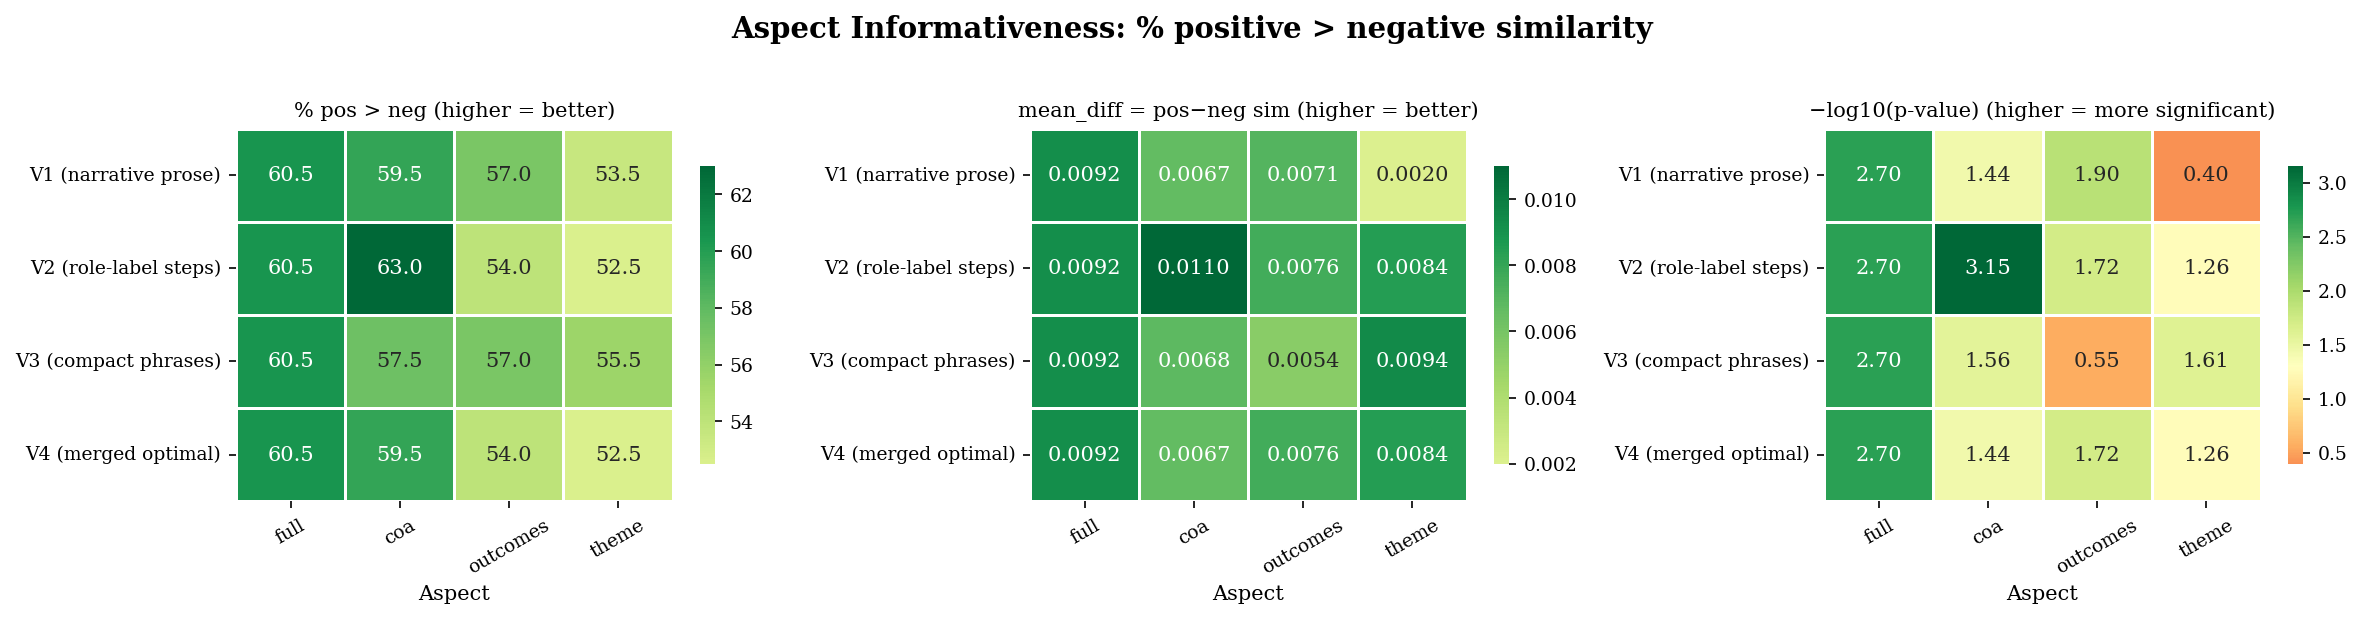

Saved: aspect_heatmap_bge_m3_384.png


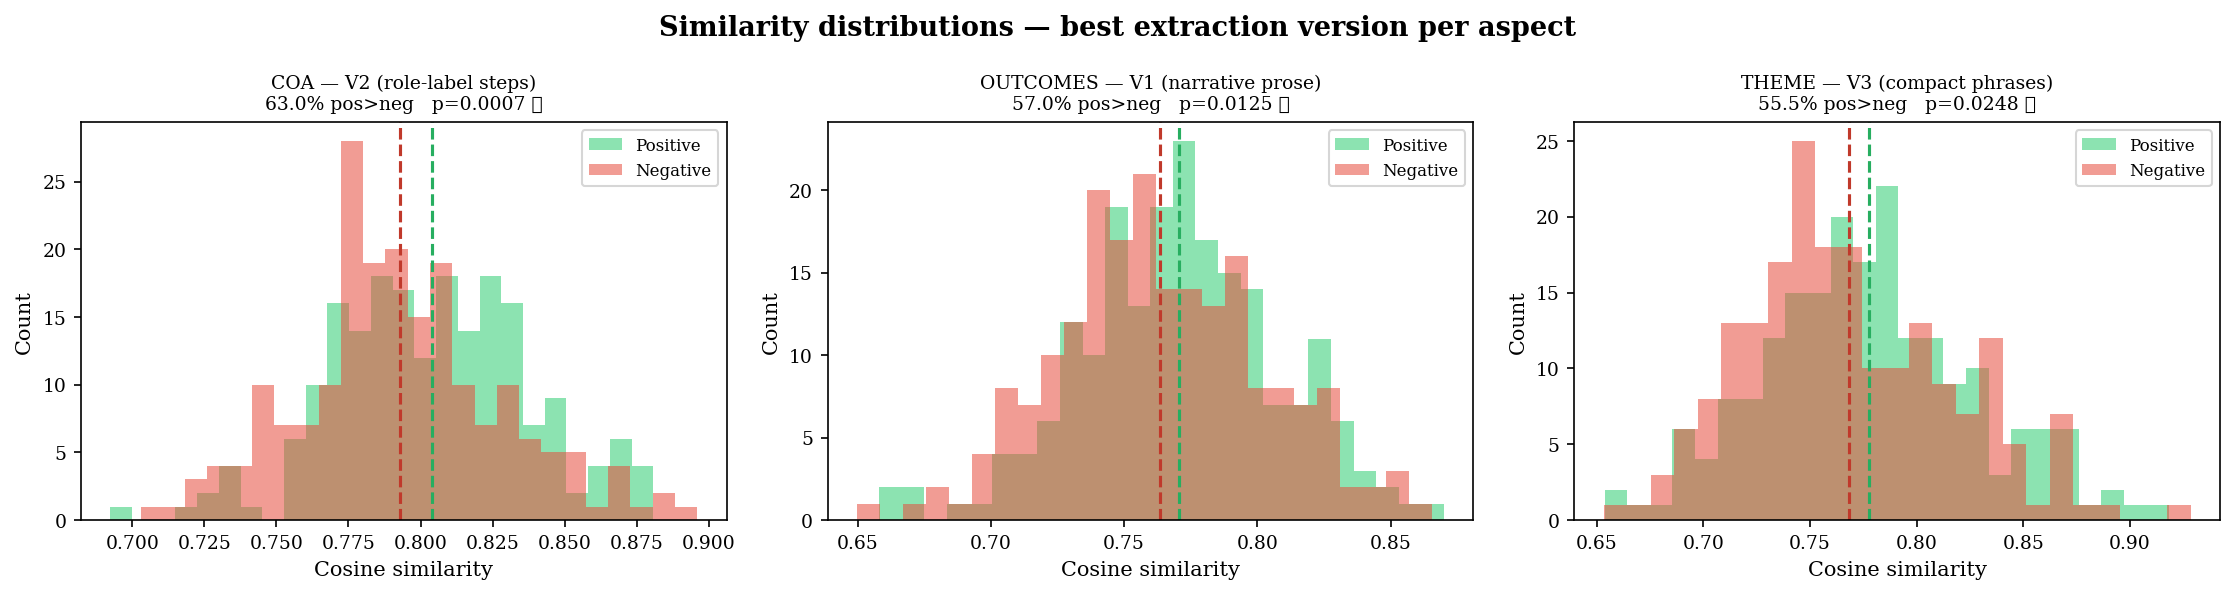

Saved: aspect_distributions_best_bge_m3_384.png


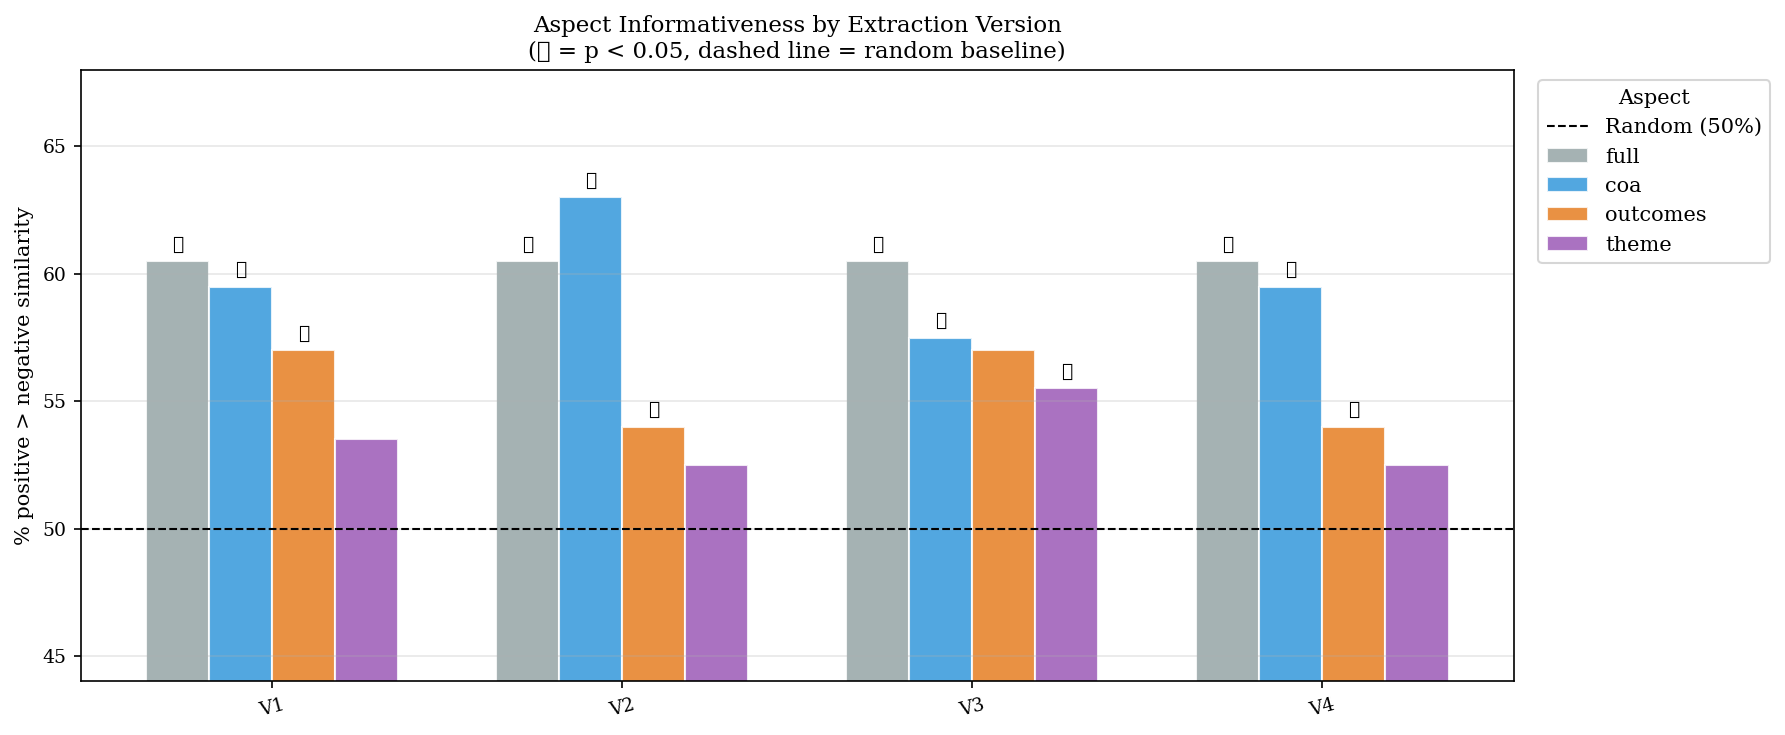

Saved: aspect_informativeness_bars_bge_m3_384.png
  INTERPRETATION

── FULL ──
  V1 (narrative prose): 60.5% pos>neg, p=0.0020
  V2 (role-label steps): 60.5% pos>neg, p=0.0020
  V3 (compact phrases): 60.5% pos>neg, p=0.0020
  V4 (merged optimal): 60.5% pos>neg, p=0.0020
  → Best version: V1 (narrative prose)

── COA ──
  V2 (role-label steps): 63.0% pos>neg, p=0.0007
  V1 (narrative prose): 59.5% pos>neg, p=0.0364
  V4 (merged optimal): 59.5% pos>neg, p=0.0364
  V3 (compact phrases): 57.5% pos>neg, p=0.0273
  → Best version: V2 (role-label steps)

── OUTCOMES ──
  V1 (narrative prose): 57.0% pos>neg, p=0.0125
  V2 (role-label steps): 54.0% pos>neg, p=0.0191
  V4 (merged optimal): 54.0% pos>neg, p=0.0191
  → Best version: V1 (narrative prose)

── THEME ──
  V3 (compact phrases): 55.5% pos>neg, p=0.0248
  → Best version: V3 (compact phrases)
  Aspect          Best version  % pos>neg  p-value Informative
    full  V1 (narrative prose)       60.5   0.0020       Yes ✓
     coa V2 (role-labe

In [3]:
# %% [markdown]
# # Aspect Informativeness Analysis for Narrative Similarity (BGE-M3)
#
# Evaluates three aspect extraction versions and a merged optimal cache
# using BGE-M3, a retrieval-oriented multi-granularity embedding model.
# For each version × aspect combination we compute:
# - **% pos > neg**: fraction of triples where positive similarity > negative similarity
# - **mean_diff**: average (pos_sim − neg_sim)
# - **p-value**: paired t-test (H₀: no difference between pos and neg similarities)
#
# A p-value < 0.05 and % pos>neg clearly above 50% indicates the aspect
# is statistically informative for narrative similarity.

# %% [code]
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

# ── Configuration ─────────────────────────────────────────────────────────────
# Model updated from all-roberta-large to BGE-M3 to test whether shorter,
# compact aspect formulations become more informative under a retrieval-tuned encoder.
DATA_DIR   = "/kaggle/input/datasets/anisoaraana/aspect-aware-narrative-similarity/"
DEV_PATH   = DATA_DIR + "dev_track_a.jsonl"

# Three extraction versions + merged cache
CACHE_PATHS = {
    "V1 (narrative prose)": DATA_DIR + "aspects_cache_v1.json",
    "V2 (role-label steps)": DATA_DIR + "aspects_cache_v2.json",
    "V3 (compact phrases)": DATA_DIR + "aspects_cache_v3.json",
    "V4 (merged optimal)":   DATA_DIR + "merged_aspects_cache.json",
}

MODEL_NAME  = "BAAI/bge-m3"
MAX_LEN     = 384
BATCH_SIZE  = 16
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
VIEWS       = ["full", "coa", "outcomes", "theme"]

print(f"Device: {DEVICE}")

# ── Load model ────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
print("Model loaded:", MODEL_NAME)


# ── Helpers ───────────────────────────────────────────────────────────────────
def _norm(text):
    return " ".join(str(text).split())


def load_cache(path):
    if not Path(path).exists():
        print(f"  Cache not found: {path}")
        return {}
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    cache = {}
    if isinstance(raw, dict):
        for k, v in raw.items():
            cache[_norm(k)] = {
                "coa":      v.get("coa") or v.get("course_of_action") or "",
                "outcomes": v.get("outcomes") or v.get("outcome") or "",
                "theme":    v.get("theme") or v.get("abstract_theme") or "",
            }
    print(f"  Loaded {len(cache)} entries")
    return cache


def get_view_text(story_text, view, cache):
    if view == "full":
        return story_text
    entry = cache.get(_norm(story_text), {})
    val   = entry.get(view, "")
    return val if val.strip() else story_text   # fallback to full text


def encode_texts(texts):
    embeddings = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch   = texts[i:i+BATCH_SIZE]
        encoded = tokenizer(batch, padding=True, truncation=True,
                            max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out   = model(**encoded)
            tok   = out.last_hidden_state
            mask  = encoded["attention_mask"].unsqueeze(-1).float()
            emb   = (tok * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
            emb   = F.normalize(emb, p=2, dim=1)
        embeddings.append(emb.cpu().numpy())
    return np.vstack(embeddings)


def evaluate_view(triples, view, cache):
    """Compute paired pos/neg similarities for one view."""
    unique = {}
    for anchor, ta, tb, _ in triples:
        for t in (anchor, ta, tb):
            if t not in unique:
                unique[t] = get_view_text(t, view, cache)

    texts  = list(unique.keys())
    embs   = encode_texts([unique[t] for t in texts])
    t2emb  = {t: torch.tensor(embs[i], device=DEVICE) for i, t in enumerate(texts)}

    pos_sims, neg_sims = [], []
    for anchor, ta, tb, closer in triples:
        ea   = t2emb[anchor].unsqueeze(0)
        epos = t2emb[ta if closer else tb].unsqueeze(0)
        eneg = t2emb[tb if closer else ta].unsqueeze(0)
        pos_sims.append(F.cosine_similarity(ea, epos).item())
        neg_sims.append(F.cosine_similarity(ea, eneg).item())

    pos_arr = np.array(pos_sims)
    neg_arr = np.array(neg_sims)
    diff    = pos_arr - neg_arr
    t_stat, p_val = stats.ttest_rel(pos_arr, neg_arr)

    # Cache hit rate (% of stories where aspect text differs from full text)
    hit_rate = sum(
        1 for t in texts
        if get_view_text(t, view, cache) != t
    ) / max(len(texts), 1) * 100

    return {
        "mean_pos":   float(pos_arr.mean()),
        "mean_neg":   float(neg_arr.mean()),
        "mean_diff":  float(diff.mean()),
        "pct_pos_gt_neg": float((diff > 0).mean() * 100),
        "t_stat":     float(t_stat),
        "p_value":    float(p_val),
        "cache_hit_%": hit_rate,
        "pos_sims":   pos_sims,
        "neg_sims":   neg_sims,
    }


# ── Load data ─────────────────────────────────────────────────────────────────
def load_triples(path):
    triples = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            triples.append((
                obj["anchor_text"], obj["text_a"], obj["text_b"],
                obj["text_a_is_closer"]
            ))
    return triples

triples = load_triples(DEV_PATH)
print(f"\nLoaded {len(triples)} dev triples")


# %% [markdown]
# ## Run Evaluation Across All Cache Versions

# %% [code]
all_results  = {}   # version → view → metrics dict
raw_sims     = {}   # version → view → {"pos": [...], "neg": [...]}

for version_name, cache_path in CACHE_PATHS.items():
    print(f"\n{'='*55}")
    print(f"  {version_name}")
    print(f"{'='*55}")
    cache = load_cache(cache_path)
    all_results[version_name] = {}
    raw_sims[version_name]    = {}

    for view in VIEWS:
        print(f"  Evaluating {view} …", end=" ", flush=True)
        res = evaluate_view(triples, view, cache)
        all_results[version_name][view] = res
        raw_sims[version_name][view]    = {
            "pos": res.pop("pos_sims"),
            "neg": res.pop("neg_sims"),
        }
        sig = "✓ p<0.05" if res["p_value"] < 0.05 else "✗"
        print(f"  pct={res['pct_pos_gt_neg']:.1f}%  "
              f"diff={res['mean_diff']:.4f}  "
              f"p={res['p_value']:.4f}  {sig}")


# %% [markdown]
# ## Summary Table

# %% [code]
rows = []
for vname, views_dict in all_results.items():
    for view, metrics in views_dict.items():
        rows.append({
            "Version":      vname,
            "Aspect":       view,
            "% pos>neg":    round(metrics["pct_pos_gt_neg"], 1),
            "mean_diff":    round(metrics["mean_diff"], 4),
            "mean_pos_sim": round(metrics["mean_pos"], 4),
            "mean_neg_sim": round(metrics["mean_neg"], 4),
            "p-value":      round(metrics["p_value"], 4),
            "Significant":  "✓" if metrics["p_value"] < 0.05 else "",
            "Cache hit %":  round(metrics["cache_hit_%"], 1),
        })

df = pd.DataFrame(rows)
# Pivot for readability
pivot_pct = df.pivot(index="Version", columns="Aspect", values="% pos>neg")[VIEWS]
pivot_p   = df.pivot(index="Version", columns="Aspect", values="p-value")[VIEWS]
pivot_diff= df.pivot(index="Version", columns="Aspect", values="mean_diff")[VIEWS]

print("\n── % pos > neg (higher is better, random baseline = 50%) ──")
print(pivot_pct.to_string())

print("\n── p-value (< 0.05 = statistically significant) ──")
print(pivot_p.to_string())

print("\n── mean_diff = mean(pos_sim − neg_sim) (higher = cleaner separation) ──")
print(pivot_diff.to_string())

# Full table
print("\n── Full table ──")
print(df.to_string(index=False))

df.to_csv("aspect_informativeness_all_versions_bge_m3.csv", index=False)
print("\nSaved: aspect_informativeness_all_versions_bge_m3.csv")


# %% [markdown]
# ## Visualisation 1 — % pos > neg heatmap across versions and aspects

# %% [code]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Aspect Informativeness: % positive > negative similarity",
             fontsize=14, fontweight="bold", y=1.02)

titles = ["% pos > neg (higher = better)",
          "mean_diff = pos−neg sim (higher = better)",
          "−log10(p-value) (higher = more significant)"]

data_matrices = [
    pivot_pct,
    pivot_diff,
    pivot_p.applymap(lambda p: -np.log10(max(p, 1e-10))),
]
cmaps   = ["RdYlGn", "RdYlGn", "RdYlGn"]
centers = [50,        0,         -np.log10(0.05)]
fmts    = [".1f",     ".4f",      ".2f"]

for ax, data, title, cmap, center, fmt in zip(
        axes, data_matrices, titles, cmaps, centers, fmts):
    sns.heatmap(
        data, ax=ax, annot=True, fmt=fmt, cmap=cmap,
        center=center, linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Aspect")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("aspect_heatmap_bge_m3_384.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: aspect_heatmap_bge_m3_384.png")


# %% [markdown]
# ## Visualisation 2 — Best version per aspect: similarity distributions

# %% [code]
# Select the best version per aspect based on % pos > neg
best_by_aspect = {}
for view in ["coa", "outcomes", "theme"]:
    best_v, best_pct = None, -1
    for vname, vdata in all_results.items():
        if vname == "V4 (merged optimal)":
            continue   # skip merged for this comparison
        pct = vdata[view]["pct_pos_gt_neg"]
        if pct > best_pct:
            best_pct = pct
            best_v   = vname
    best_by_aspect[view] = (best_v, best_pct)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Similarity distributions — best extraction version per aspect",
             fontsize=13, fontweight="bold")

for ax, view in zip(axes, ["coa", "outcomes", "theme"]):
    best_v, best_pct = best_by_aspect[view]
    pos = raw_sims[best_v][view]["pos"]
    neg = raw_sims[best_v][view]["neg"]
    p   = all_results[best_v][view]["p_value"]
    sig = "p={:.4f} ✓".format(p) if p < 0.05 else "p={:.4f} ✗".format(p)

    ax.hist(pos, bins=25, alpha=0.55, color="#2ecc71", label="Positive")
    ax.hist(neg, bins=25, alpha=0.55, color="#e74c3c", label="Negative")
    ax.axvline(np.mean(pos), color="#27ae60", linestyle="--", linewidth=1.5)
    ax.axvline(np.mean(neg), color="#c0392b", linestyle="--", linewidth=1.5)
    ax.set_title(f"{view.upper()} — {best_v}\n"
                 f"{best_pct:.1f}% pos>neg   {sig}", fontsize=9)
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("aspect_distributions_best_bge_m3_384.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: aspect_distributions_best_bge_m3_384.png")


# %% [markdown]
# ## Visualisation 3 — Full text vs best aspect per version (bar chart)

# %% [code]
fig, ax = plt.subplots(figsize=(12, 5))

versions  = list(all_results.keys())
x         = np.arange(len(versions))
bar_w     = 0.18
colors    = {"full": "#95a5a6", "coa": "#3498db",
             "outcomes": "#e67e22", "theme": "#9b59b6"}

for i, view in enumerate(VIEWS):
    pcts = [all_results[v][view]["pct_pos_gt_neg"] for v in versions]
    bars = ax.bar(x + i * bar_w, pcts, bar_w, label=view,
                  color=colors[view], alpha=0.85, edgecolor="white")
    # Mark significant bars
    for bar, vname in zip(bars, versions):
        p = all_results[vname][view]["p_value"]
        if p < 0.05:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3, "✓",
                    ha="center", va="bottom", fontsize=9, color="black")

ax.axhline(50, color="black", linestyle="--", linewidth=1, label="Random (50%)")
ax.set_xticks(x + bar_w * (len(VIEWS)-1) / 2)
ax.set_xticklabels([v.split("(")[0].strip() for v in versions], rotation=15)
ax.set_ylabel("% positive > negative similarity")
ax.set_title("Aspect Informativeness by Extraction Version\n"
             "(✓ = p < 0.05, dashed line = random baseline)",
             fontsize=11)
ax.set_ylim(44, 68)
ax.legend(title="Aspect", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("aspect_informativeness_bars_bge_m3_384.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: aspect_informativeness_bars_bge_m3_384.png")


# %% [code]
print("=" * 70)
print("  INTERPRETATION")
print("=" * 70)

sig_threshold = 0.05
for view in VIEWS:
    print(f"\n── {view.upper()} ──")
    sig_versions = [
        (vname, all_results[vname][view])
        for vname in all_results
        if all_results[vname][view]["p_value"] < sig_threshold
    ]
    if not sig_versions:
        print(f"  No version is statistically significant (p < {sig_threshold})")
        print(f"  → {view} does NOT reliably discriminate narrative similarity")
        print(f"    in this dataset. Avoid as the sole input for training.")
    else:
        for vname, metrics in sorted(sig_versions,
                                     key=lambda x: -x[1]["pct_pos_gt_neg"]):
            print(f"  {vname}: {metrics['pct_pos_gt_neg']:.1f}% pos>neg, "
                  f"p={metrics['p_value']:.4f}")
        best_vname = max(sig_versions, key=lambda x: x[1]["pct_pos_gt_neg"])[0]
        print(f"  → Best version: {best_vname}")

# Save final recommendation table
rec = []
for view in VIEWS:
    all_v = [(vname, all_results[vname][view]) for vname in all_results
             if vname != "V4 (merged optimal)"]
    best  = max(all_v, key=lambda x: x[1]["pct_pos_gt_neg"])
    sig   = best[1]["p_value"] < 0.05
    rec.append({
        "Aspect":      view,
        "Best version": best[0],
        "% pos>neg":   round(best[1]["pct_pos_gt_neg"], 1),
        "p-value":     round(best[1]["p_value"], 4),
        "Informative": "Yes ✓" if sig else "No ✗",
    })

df_rec = pd.DataFrame(rec)
print(df_rec.to_string(index=False))
df_rec.to_csv("aspect_recommendations_bge_m3_384.csv", index=False)
print("\nSaved: aspect_recommendations_bge_m3_384.csv")